# Medical Cost prediction Notebook

## Dataset importing 

In [2]:
import pandas as pd
import os 
cur=os.getcwd()
bas_dir=os.path.dirname(cur)
path=os.path.join(bas_dir,'data','insurance.csv')
df=pd.read_csv(path)

## Analysis

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.shape

(1338, 7)

In [6]:
df['region'].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
#Checking Missing values
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

- There is no missing values

## Analysis

<Axes: xlabel='charges', ylabel='Count'>

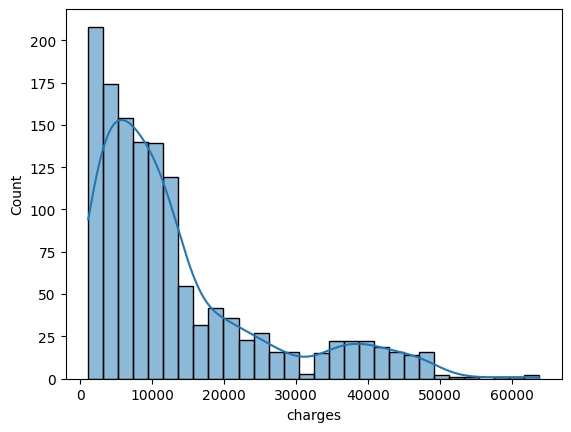

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['charges'],kde='True')

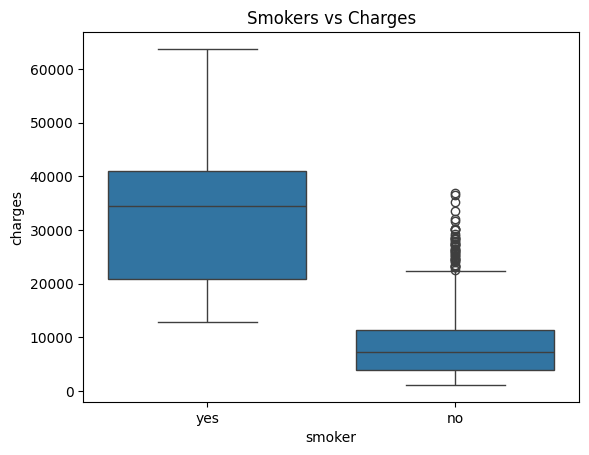

In [10]:
sns.boxplot(x='smoker',y='charges',data=df)
plt.title('Smokers vs Charges')
plt.show()


Smokers vs charges Insight
- The above Figure shows that the smokers have a higher charges compare to non smokers

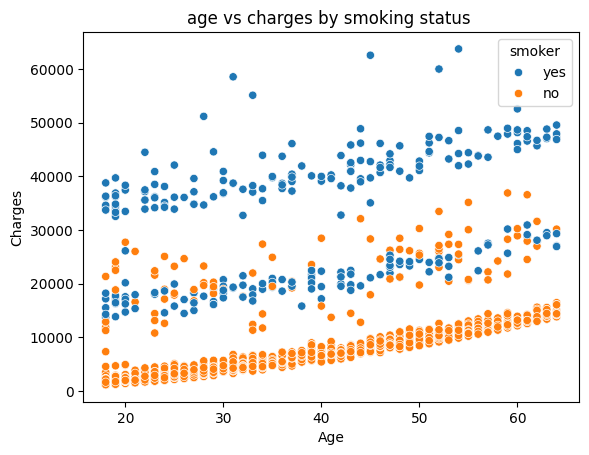

In [11]:
sns.scatterplot(data=df, x='age', y='charges',hue='smoker')
plt.title('age vs charges by smoking status ')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

Age VS Charges by smoking status
- Medical charges increase with age for both smokers and non-smokers. However, smokers incur significantly higher costs across all age groups. The difference becomes more pronounced at higher ages, indicating that smoking combined with aging leads to substantially higher medical expenses.

Text(0.5, 1.0, 'Age VS Charges')

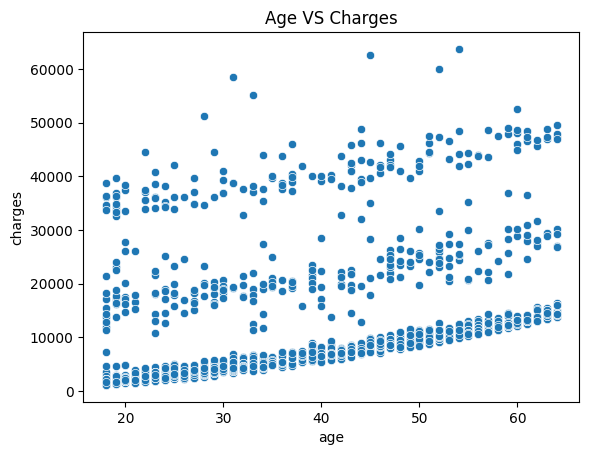

In [12]:
# Age vs charges
sns.scatterplot(x='age',y='charges',data=df)
plt.title('Age VS Charges')

Text(0.5, 1.0, 'Bmi VS charges')

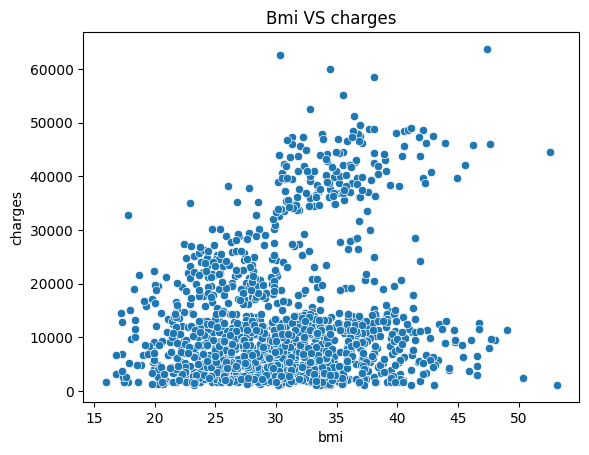

In [13]:
sns.scatterplot(x='bmi',y='charges',data=df)
plt.title('Bmi VS charges')

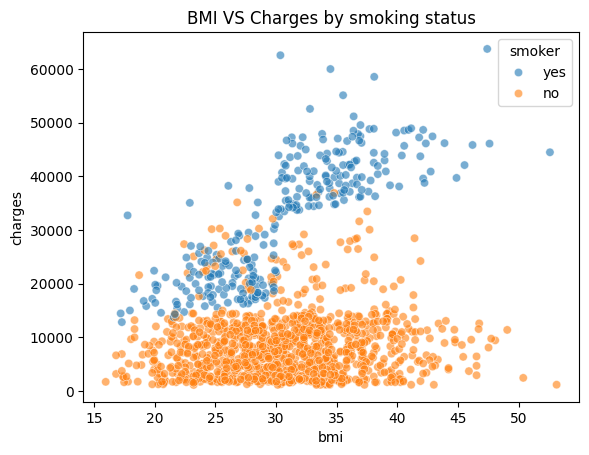

In [14]:
sns.scatterplot(data=df, x='bmi', y='charges',hue='smoker',alpha =0.6)
plt.title('BMI VS Charges by smoking status')
plt.show()

BMI vs Charges by Smoking status
- Individuals with higher BMI tend to have increased medical charges, especially among smokers. Smokers with high BMI show the highest costs, while non-smokers generally have lower charges even at higher BMI levels. This suggests a combined effect of smoking and BMI on medical expenses.

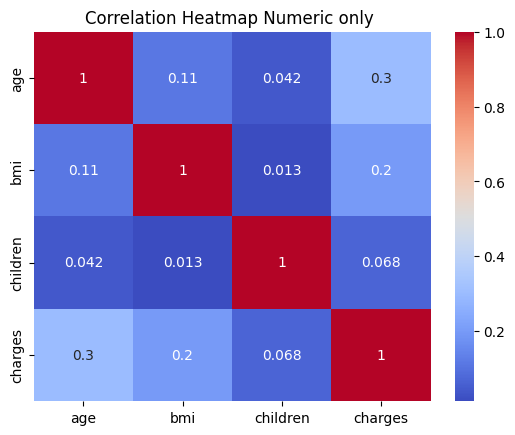

In [15]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap Numeric only ')
plt.show()

## Pre Processing


In [16]:
#one-hot encoding
df=pd.get_dummies(df,drop_first=True)

One-Hot Encoding

- Categorical variables such as sex, smoker, and region were converted into numerical format using one-hot encoding.

- This was necessary because machine learning models require numerical input and cannot directly process categorical data.

- One-hot encoding was specifically chosen to avoid introducing any ordinal relationship between categories. For example, assigning values like 0, 1, 2 to categories such as regions would incorrectly imply an order, which does not exist.

- Therefore, one-hot encoding ensures that each category is treated independently without adding misleading relationships.

In [17]:
bool_col=df.select_dtypes(include='bool').columns
df[bool_col]=df[bool_col].astype(int)

Converted the Boolean columns to Numeric for ML models 

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   bmi               1338 non-null   float64
 2   children          1338 non-null   int64  
 3   charges           1338 non-null   float64
 4   sex_male          1338 non-null   int64  
 5   smoker_yes        1338 non-null   int64  
 6   region_northwest  1338 non-null   int64  
 7   region_southeast  1338 non-null   int64  
 8   region_southwest  1338 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 94.2 KB


In [19]:
df.describe()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265,0.505232,0.204783,0.242900,0.272048,0.242900
std,14.049960,6.098187,1.205493,12110.011237,0.500160,0.403694,0.428995,0.445181,0.428995
min,18.000000,15.960000,0.000000,1121.873900,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,26.296250,0.000000,4740.287150,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,30.400000,1.000000,9382.033000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,51.000000,34.693750,2.000000,16639.912515,1.000000,0.000000,0.000000,1.000000,0.000000
max,64.000000,53.130000,5.000000,63770.428010,1.000000,1.000000,1.000000,1.000000,1.000000


Text(0.5, 1.0, ' Heatmap ')

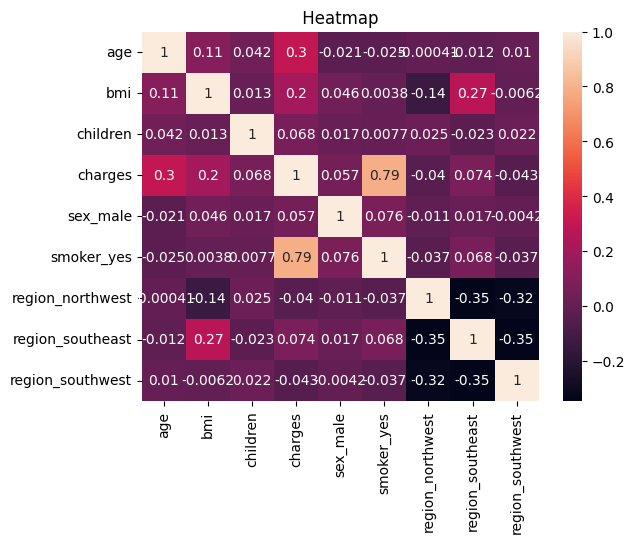

In [20]:
sns.heatmap(df.corr(),annot= True)
plt.title(" Heatmap ")

Correlation Matrix Insight
- `smoker_yes`: Shows the strongest positive correlation with medical charges, indicating that smoking significantly increases healthcare costs.
- `age`: Exhibits a moderate positive correlation, suggesting that medical expenses tend to increase with age.
- `bmi` : Shows a weaker positive correlation, indicating that higher BMI has some impact on medical costs, but less than smoking and age.

In [21]:
X=df.drop('charges',axis=1)
y=df['charges']

## Spliting Data

In [22]:
# Train and test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Training Model

In [23]:
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor
lr_model=LinearRegression()
lr_model.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
ridge=Ridge(alpha=1.0)
lasso=Lasso(alpha=0.1)
rf_model=RandomForestRegressor()

In [25]:
ridge.fit(X_train,y_train)
lasso.fit(X_train,y_train)
rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Evaluating model

In [26]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
def evaluate(model,name):
    y_pred=model.predict(X_test)
    print(f"{name}")
    print("MAE:", mean_absolute_error(y_test,y_pred))
    print("MSE:", mean_squared_error(y_test,y_pred))
    print("R2:",r2_score(y_test,y_pred))

In [ ]:
evaluate(lr_model,"LinearRegression")
evaluate(rf_model,"RandomForestRegressor")
evaluate(ridge,"Ridge")
evaluate(lasso,"Lasso")

LinearRegression
MAE: 4181.194473753654
MSE: 33596915.85136146
R2: 0.7835929767120723
RandomForestRegressor
MAE: 2621.0184413294783
MSE: 21550579.98604497
R2: 0.8611867563814077
Ridge
MAE: 4193.585298299828
MSE: 33645037.09177904
R2: 0.7832830144988214
Lasso
MAE: 4181.31763185589
MSE: 33597770.054583974
R2: 0.7835874745529608


Model Evaluation Insight
- Linear Regression achieved an $R^2$ score of ~0.78.Providing a solid baseline performance for predicting medical charges.
- Ridge and Lasso Regression showed performance similar to Linear Regression, indicating that regularization did not significantly improve the model. This suggests that the dataset does not suffer heavily from overfitting or multicollinearity.
- Random Forest Regressor outperformed all other models with the highest R² score of ~0.87 and significantly lower MAE and MSE values. This indicates that it captures complex non-linear relationships in the data more effectively.
- Overall, ensemble methods like Random Forest are better suited for this problem due to their ability to model interactions between features such as smoking status, BMI, and age.

## Feature Importance

In [28]:
feature_importance=rf_model.feature_importances_
features=X.columns

importance_df=pd.DataFrame({
    "Feature":features,
    "Importance":feature_importance
}).sort_values(by="Importance",ascending=False)


In [29]:
print(importance_df)

            Feature  Importance
4        smoker_yes    0.604560
1               bmi    0.217288
0               age    0.136182
2          children    0.019912
3          sex_male    0.006855
6  region_southeast    0.005733
5  region_northwest    0.005296
7  region_southwest    0.004174


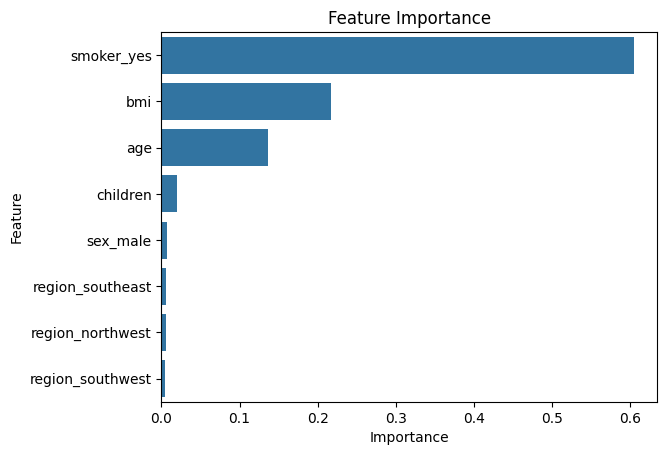

In [30]:
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance")
plt.show()

Feature Importance Insights
- Smoking status (smoker_yes) is the most influential feature affecting medical charges, indicating that smokers incur significantly higher healthcare costs.
- BMI and age also contribute notably, suggesting that higher body mass index and increasing age are associated with increased medical expenses.
- Other features such as gender, number of children, and region have relatively lower impact on prediction.
- This aligns with real-world expectations, where lifestyle and health-related factors play a major role in determining medical costs.